# Support Vector Machines (SVM) — Interactive Tutorial
# 支持向量机交互式教程

**Course:** CST8506 Advanced Machine Learning — Week 2

This notebook walks you through SVM step by step:
1. The problem: How do we draw the "best" line between two groups?
2. The solution: Find the **widest gap** (margin) between classes
3. What happens when data overlaps? → **Soft margin** (C parameter)
4. What happens when data isn't separable by a line? → **Kernel trick**
5. Key parameters: **C** and **gamma**

**Run each cell in order. Change the parameters and re-run to see what happens!**

In [1]:
# 导入所有需要的库
# Import all required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_blobs, make_circles, make_moons
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap

%matplotlib inline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 配色方案
# Color scheme
COLORS_LIGHT = ListedColormap(["#FFAAAA", "#AAAAFF"])
COLORS_BOLD = ["#FF4444", "#4444FF"]


def plot_decision_boundary(clf, X, y, ax, title, show_margin=True, show_sv=True):
    """Plot SVM decision boundary with optional margin and support vectors."""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=COLORS_LIGHT)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c=COLORS_BOLD[0],
               edgecolors="k", s=50, label="Class 0")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c=COLORS_BOLD[1],
               edgecolors="k", s=50, label="Class 1")

    if show_margin:
        Z_d = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        ax.contour(xx, yy, Z_d, levels=[-1, 0, 1],
                   linestyles=["--", "-", "--"], colors="k", linewidths=[1, 2, 1])

    if show_sv and hasattr(clf, "support_vectors_"):
        ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
                   s=200, facecolors="none", edgecolors="lime", linewidths=2,
                   label=f"Support Vectors (n={len(clf.support_vectors_)})")

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(loc="best", fontsize=8)

print("Setup complete!")

Setup complete!


---
## 1. The Problem: Which Line is "Best"?
## 问题：哪条线才是"最好"的？

Imagine you have two groups of points on a 2D plane. You can draw many lines to separate them, but which one is optimal?

想象一下，二维平面上有两组点。你可以画很多条线把它们分开，但哪条才是最优的？

**SVM's answer:** Pick the line with the **widest gap** (called **margin**) between the two classes. The wider the gap, the more confident we are that new points will be classified correctly.

**SVM 的答案：** 选择两类之间**间隔最宽**的那条线（称为 **margin**，间隔）。间隔越宽，对新数据的分类就越有把握。

### Key terms

| Term | Meaning |
|------|--------|
| **Hyperplane** (超平面) | The decision boundary. In 2D it's a line, in 3D a plane, in higher dimensions a hyperplane |
| **Margin** (间隔) | The distance between the hyperplane and the closest data points on each side |
| **Support Vectors** (支持向量) | The data points that sit closest to the hyperplane — they "support" (determine) its position |

Let's see this in action. We use `make_blobs` (a scikit-learn function that generates clusters of random points) to create two well-separated groups. The `cluster_std` parameter controls how spread out each group is — lower values produce tighter clusters.

我们用 `make_blobs`（scikit-learn 中生成随机点簇的函数）创建两组分离良好的点。`cluster_std` 参数控制每组的分散程度——值越小，点簇越紧密。

In [2]:
# 生成线性可分数据
# Generate linearly separable data
X_linear, y_linear = make_blobs(n_samples=100, centers=2,
                                random_state=RANDOM_STATE, cluster_std=1.2)

clf_linear = SVC(kernel="linear", C=1.0)
clf_linear.fit(X_linear, y_linear)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


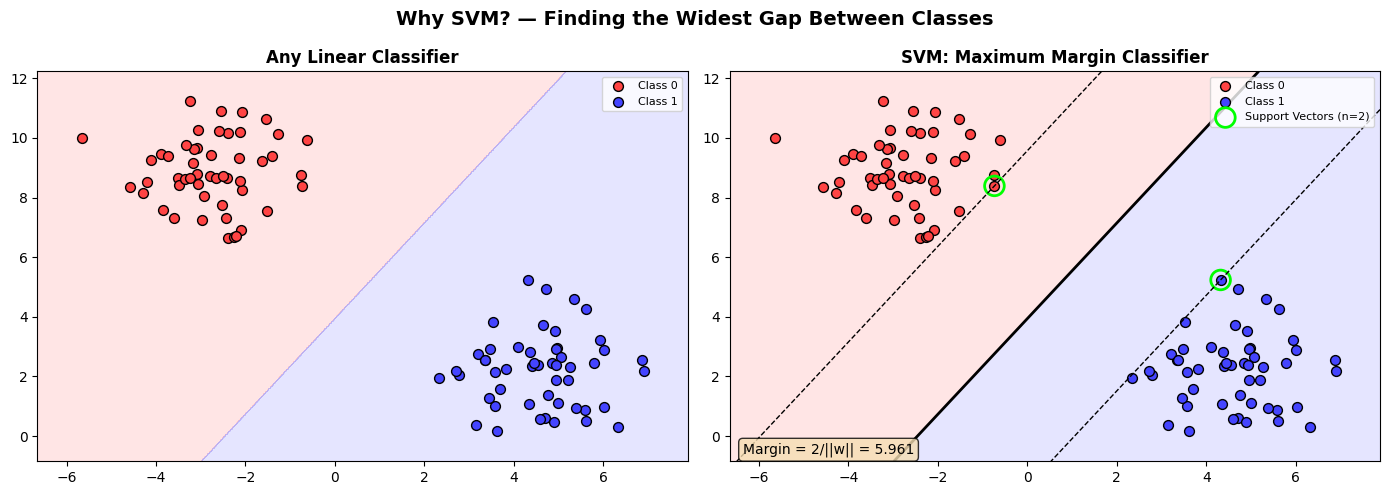

Margin width: 5.9613
Weight vector w = [ 0.28465809 -0.17755842]
Bias b = 0.6996
Number of support vectors: 2


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：只看分类结果，没有间隔线
# Left: classification only, no margin
plot_decision_boundary(clf_linear, X_linear, y_linear, axes[0],
                       "Any Linear Classifier", show_margin=False, show_sv=False)

# 右图：SVM 的视角——间隔线 + 支持向量
# Right: SVM view — margin lines + support vectors
plot_decision_boundary(clf_linear, X_linear, y_linear, axes[1],
                       "SVM: Maximum Margin Classifier")

w = clf_linear.coef_[0]
margin = 2 / np.linalg.norm(w)
axes[1].text(0.02, 0.02, f"Margin = 2/||w|| = {margin:.3f}",
             transform=axes[1].transAxes, fontsize=10,
             bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

plt.suptitle("Why SVM? — Finding the Widest Gap Between Classes", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Margin width: {margin:.4f}")
print(f"Weight vector w = {w}")
print(f"Bias b = {clf_linear.intercept_[0]:.4f}")
print(f"Number of support vectors: {len(clf_linear.support_vectors_)}")

### How the math works (behind the scenes)
### 数学原理（幕后）

The decision boundary is defined by: **w·x + b = 0**

- **w** is the weight vector (perpendicular to the boundary)
- **b** is the bias (shifts the boundary)
- The margin width = **2 / ||w||** (where ||w|| is the length of w)

SVM tries to **minimize ||w||** (make w small → make margin wide), while keeping all points correctly classified.

The green circles in the right plot are **support vectors** — only these points determine where the boundary goes. All other points could move freely without changing the result.

> **Try it:** Change `cluster_std=1.2` above to `0.5` (more separated) or `2.0` (more overlapping) and re-run. Watch how the margin changes!

To demonstrate the C parameter, we generate data with `cluster_std=2.5` (more spread out than before), which creates significant overlap between the two classes. This simulates real-world data where groups are not perfectly separated.

为了演示 C 参数，我们生成 `cluster_std=2.5` 的数据（比之前更分散），使两类之间有明显重叠。这模拟了现实中各类别并不完全分离的情况。

---
## 2. The C Parameter: How Strict Should We Be?
## C 参数：我们应该多严格？

Real data is messy. Sometimes the two groups overlap and no perfect line exists.

现实数据是混乱的。有时两组数据会重叠，不存在完美的分割线。

The **C parameter** controls the trade-off:
- **Large C** (e.g., 100): "Classify everything correctly!" → narrow margin, risk of **overfitting**
- **Small C** (e.g., 0.01): "It's OK to make some mistakes" → wide margin, risk of **underfitting**

Think of C as a "strictness dial":

| C value | Behavior | Risk |
|---------|----------|------|
| C → ∞ | Zero tolerance for errors (hard margin = MMC) | Overfitting |
| C = 1.0 | Default balance (sklearn default) | — |
| C → 0 | Very tolerant, wide margin | Underfitting |

In [4]:
# 生成有重叠的数据
# Generate overlapping data
X_overlap, y_overlap = make_blobs(n_samples=150, centers=2,
                                  random_state=RANDOM_STATE, cluster_std=2.5)

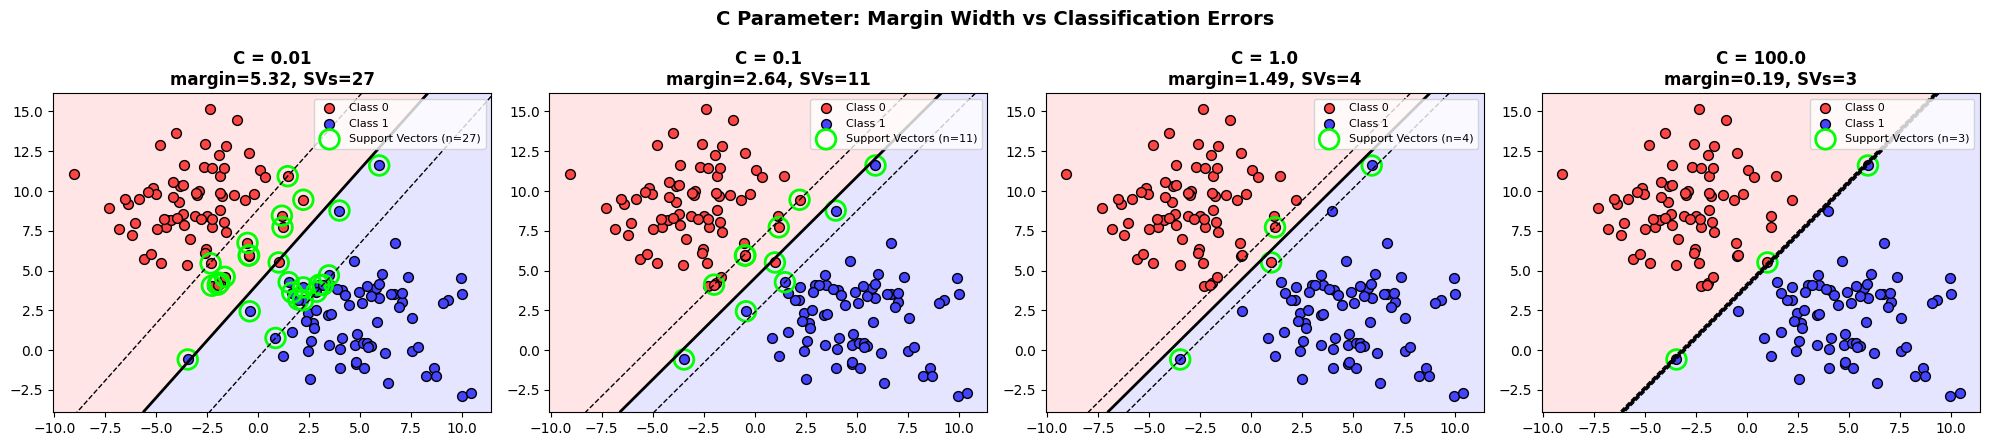

In [5]:
# ========== 试一试：修改这个列表中的 C 值 ==========
# ========== Try it: change the C values below ==========
c_values = [0.01, 0.1, 1.0, 100.0]

fig, axes = plt.subplots(1, len(c_values), figsize=(5 * len(c_values), 4.5))

for ax, c_val in zip(axes, c_values):
    clf = SVC(kernel="linear", C=c_val)
    clf.fit(X_overlap, y_overlap)
    w = clf.coef_[0]
    margin = 2 / np.linalg.norm(w)
    n_sv = len(clf.support_vectors_)
    plot_decision_boundary(clf, X_overlap, y_overlap, ax,
                           f"C = {c_val}\nmargin={margin:.2f}, SVs={n_sv}")

plt.suptitle("C Parameter: Margin Width vs Classification Errors",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

> **What to try:**
> - Change `c_values` to `[0.001, 0.01, 10.0, 1000.0]` — extreme values show the effect more clearly
> - Notice: smaller C → more support vectors, wider margin
> - Notice: larger C → fewer support vectors, narrower margin

---
## 3. Why Kernels? When a Straight Line Won't Work
## 为什么需要核函数？当直线无法解决问题

Some data simply cannot be separated by a straight line. For example, imagine one class forming a ring around the other.

有些数据根本无法用直线分开。例如，一个类形成环形包围另一个类。

**The idea:** If data isn't separable in its current space, maybe it IS separable in a higher-dimensional space. The **kernel trick** lets us compute in that higher space without actually transforming the data — saving time and memory.

**核心思想：** 如果数据在当前空间不可分，也许在更高维空间中可以分开。**核技巧 (kernel trick)** 让我们可以在高维空间中计算，而无需实际转换数据——节省时间和内存。

### Common kernels

| Kernel | Formula | When to use |
|--------|---------|-------------|
| **Linear** | K(x,y) = x·y | Data is (nearly) linearly separable |
| **Polynomial** | K(x,y) = (γ·x·y + r)^d | Moderate non-linearity |
| **RBF (Gaussian)** | K(x,y) = exp(-γ·‖x-y‖²) | Most cases — try this first! |
| **Sigmoid** | K(x,y) = tanh(γ·x·y + r) | Rarely used |

In [6]:
# 两种经典的非线性数据集
# Two classic non-linear datasets
X_circles, y_circles = make_circles(n_samples=200, noise=0.1,
                                     factor=0.4, random_state=RANDOM_STATE)
X_moons, y_moons = make_moons(n_samples=200, noise=0.15,
                               random_state=RANDOM_STATE)

scaler_c = StandardScaler()
scaler_m = StandardScaler()
X_circles_s = scaler_c.fit_transform(X_circles)
X_moons_s = scaler_m.fit_transform(X_moons)

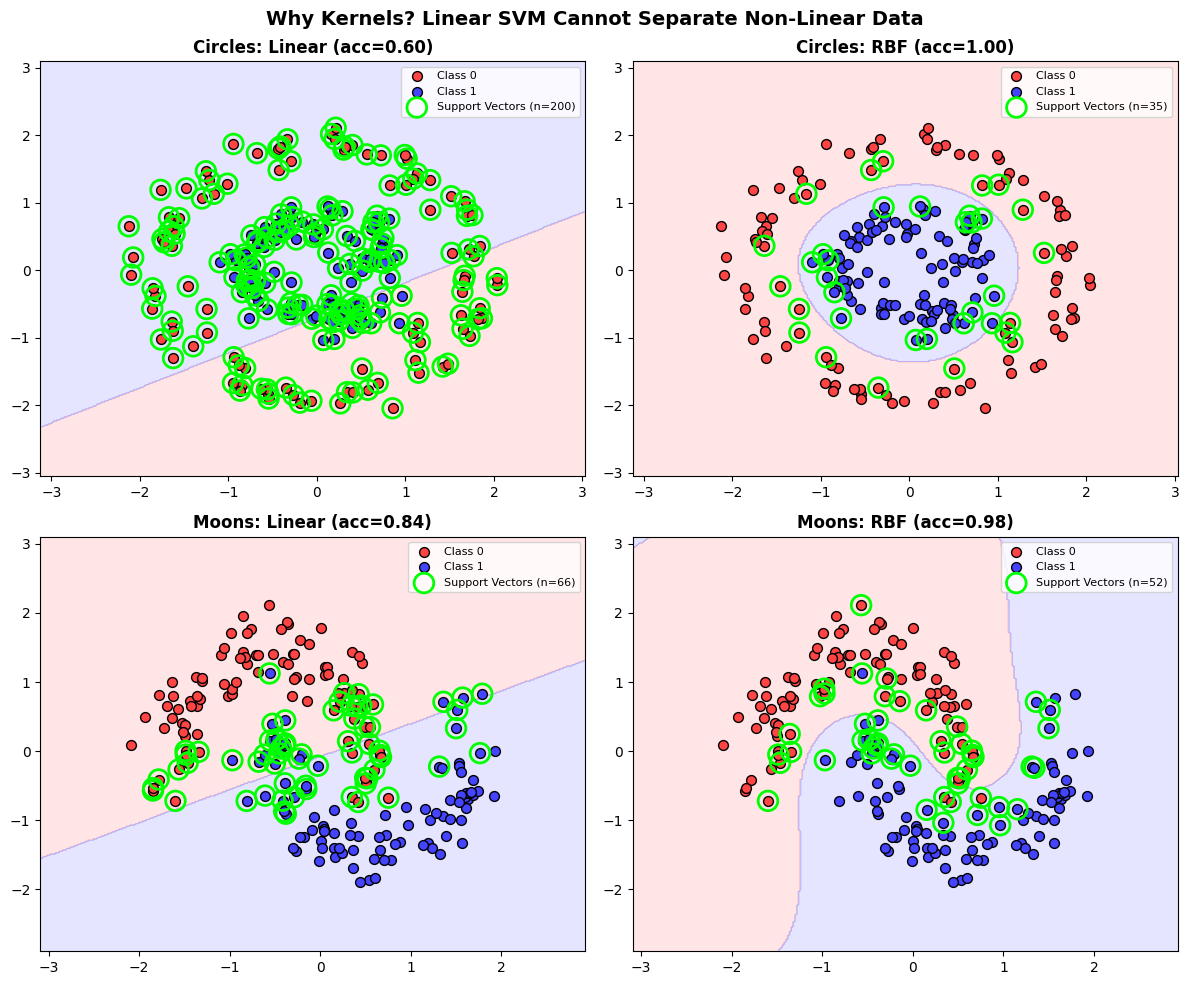

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for row, (X, y, name) in enumerate([(X_circles_s, y_circles, "Circles"),
                                     (X_moons_s, y_moons, "Moons")]):
    # 线性核 → 失败
    # Linear kernel → fails
    clf_lin = SVC(kernel="linear", C=1.0)
    clf_lin.fit(X, y)
    acc_lin = clf_lin.score(X, y)
    plot_decision_boundary(clf_lin, X, y, axes[row, 0],
                           f"{name}: Linear (acc={acc_lin:.2f})", show_margin=False)

    # RBF 核 → 成功
    # RBF kernel → works
    clf_rbf = SVC(kernel="rbf", C=1.0, gamma="scale")
    clf_rbf.fit(X, y)
    acc_rbf = clf_rbf.score(X, y)
    plot_decision_boundary(clf_rbf, X, y, axes[row, 1],
                           f"{name}: RBF (acc={acc_rbf:.2f})", show_margin=False)

plt.suptitle("Why Kernels? Linear SVM Cannot Separate Non-Linear Data",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

> **What to try:**
> - Change `noise=0.15` in `make_moons` to `0.3` (noisier) or `0.05` (cleaner)
> - Change `factor=0.4` in `make_circles` to `0.1` (tiny inner ring) or `0.8` (rings close together)
> - Try replacing `"rbf"` with `"poly"` — does it work as well?

---
## 4. Kernel Comparison: Which Kernel Fits Best?
## 核函数对比：哪个核最合适？

Different kernels create different shapes of decision boundaries. Let's compare all four on the same dataset.

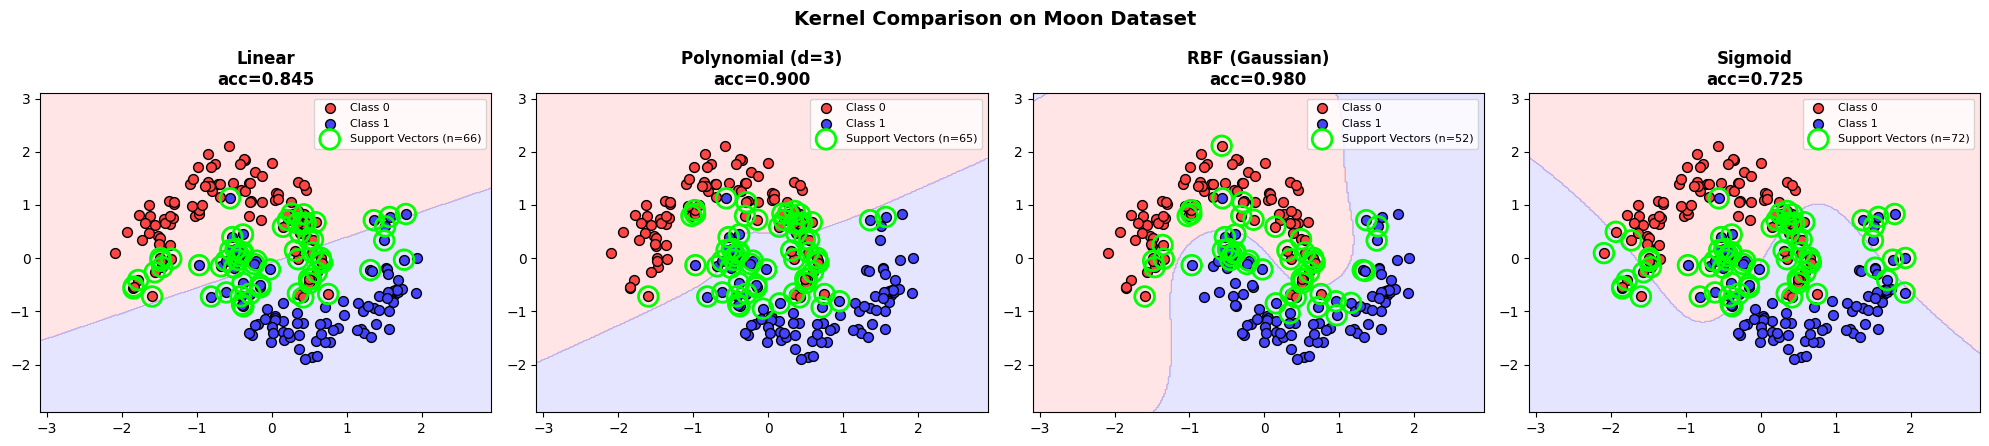

In [8]:
kernels = [
    ("linear", {}, "Linear"),
    ("poly", {"degree": 3, "gamma": "scale"}, "Polynomial (d=3)"),
    ("rbf", {"gamma": "scale"}, "RBF (Gaussian)"),
    ("sigmoid", {"gamma": "scale"}, "Sigmoid"),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (kernel, params, title) in zip(axes, kernels):
    clf = SVC(kernel=kernel, C=1.0, **params)
    clf.fit(X_moons_s, y_moons)
    acc = clf.score(X_moons_s, y_moons)
    plot_decision_boundary(clf, X_moons_s, y_moons, ax,
                           f"{title}\nacc={acc:.3f}", show_margin=False)

plt.suptitle("Kernel Comparison on Moon Dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

> **What to try:**
> - Change `degree` in polynomial kernel: try 2, 5, 10
> - Run the same comparison on `X_circles_s` instead of `X_moons_s`
> - Add `C=10.0` or `C=0.01` to see how C interacts with kernel choice

---
## 5. The Gamma Parameter: How "Far" Should Each Point Reach?
## Gamma 参数：每个点的"影响范围"有多大？

For the RBF (Radial Basis Function) kernel, **gamma** controls how much influence a single training point has:

对于 RBF（径向基函数）核，**gamma** 控制单个训练点的影响范围：

- **Small gamma** (e.g., 0.1): Each point influences a **large area** → smooth boundary → risk of **underfitting**
- **Large gamma** (e.g., 10): Each point influences only its **immediate neighbors** → wiggly boundary → risk of **overfitting**

| gamma | Boundary shape | Risk |
|-------|---------------|------|
| Small (0.01-0.1) | Very smooth, almost linear | Underfitting |
| Medium (0.5-2.0) | Balanced curves | Good fit |
| Large (5-100) | Very wiggly, memorizes data | Overfitting |

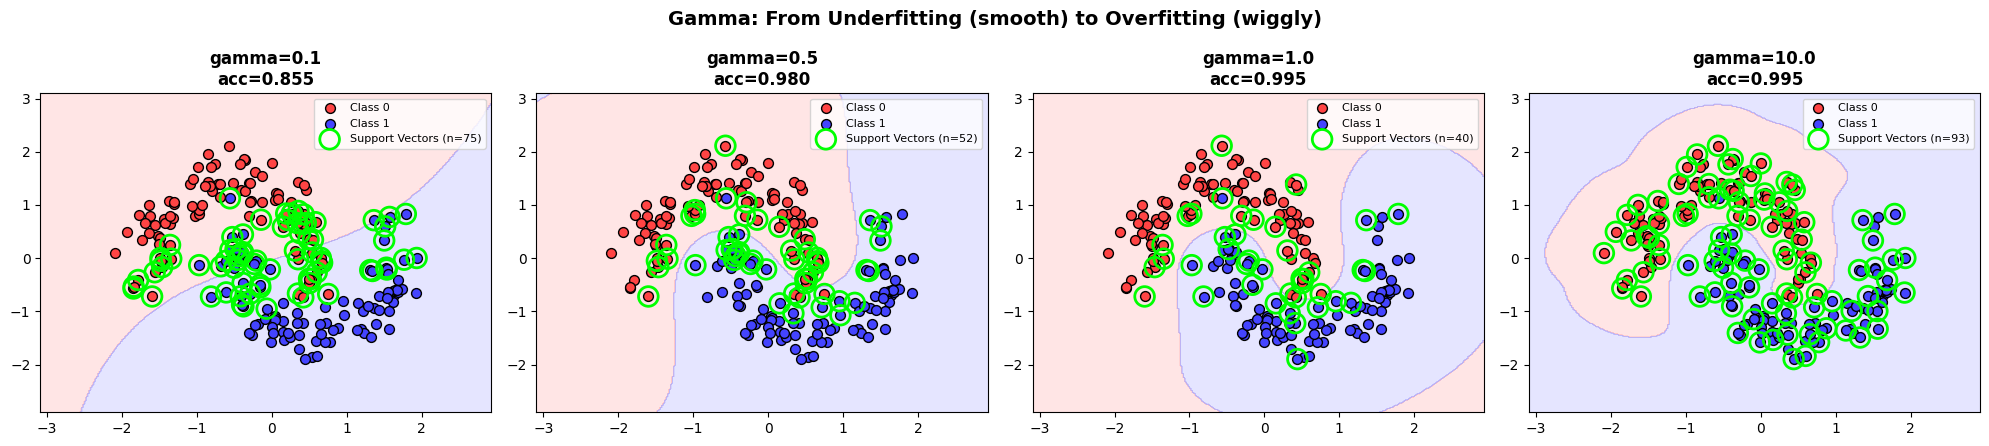

In [9]:
# ========== 试一试：修改 gamma 值 ==========
# ========== Try it: change gamma values ==========
gamma_values = [0.1, 0.5, 1.0, 10.0]

fig, axes = plt.subplots(1, len(gamma_values), figsize=(5 * len(gamma_values), 4.5))
for ax, gval in zip(axes, gamma_values):
    clf = SVC(kernel="rbf", C=1.0, gamma=gval)
    clf.fit(X_moons_s, y_moons)
    acc = clf.score(X_moons_s, y_moons)
    plot_decision_boundary(clf, X_moons_s, y_moons, ax,
                           f"gamma={gval}\nacc={acc:.3f}", show_margin=False)

plt.suptitle("Gamma: From Underfitting (smooth) to Overfitting (wiggly)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

> **What to try:**
> - Use extreme values: `gamma_values = [0.001, 0.01, 50.0, 500.0]`
> - Combine with different C: set `C=0.1` or `C=100` above
> - Notice: high gamma + high C = severe overfitting (boundary wraps around individual points)

---
## 6. The Big Picture: MMC → SVC → SVM
## 全局视角：MMC → SVC → SVM 的演进

SVM evolved in three stages:

| Method | Full Name | What it does |
|--------|-----------|-------------|
| **MMC** | Maximum Margin Classifier (最大间隔分类器) | Hard margin + linear boundary. Requires perfectly separable data. |
| **SVC** | Support Vector Classifier (支持向量分类器) | Soft margin + linear boundary. Allows some errors (C parameter). |
| **SVM** | Support Vector Machine (支持向量机) | Soft margin + kernel boundary. Handles non-linear data. |

Each stage adds flexibility:
- MMC → SVC: "Allow some mistakes" (introduce C)
- SVC → SVM: "Use curves, not just lines" (introduce kernels)

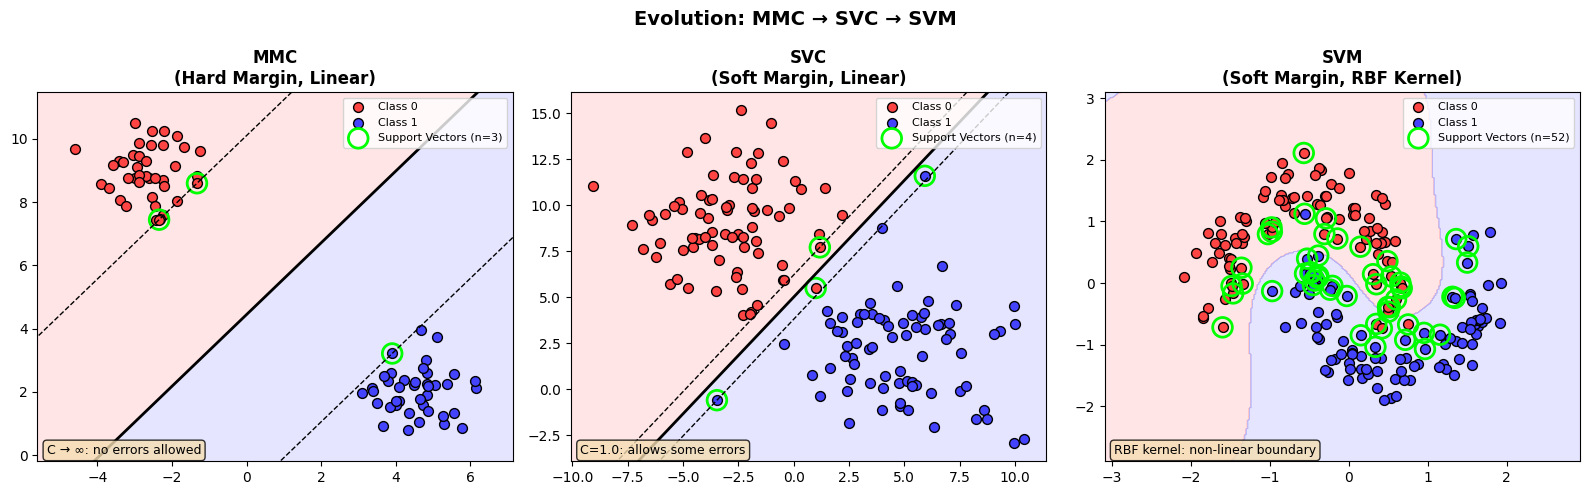

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# MMC: 硬间隔（C 非常大 → 不允许误分类）
# MMC: Hard margin (very large C → no misclassification allowed)
X_clean, y_clean = make_blobs(n_samples=80, centers=2,
                              random_state=RANDOM_STATE, cluster_std=0.8)
clf_mmc = SVC(kernel="linear", C=1e6)
clf_mmc.fit(X_clean, y_clean)
plot_decision_boundary(clf_mmc, X_clean, y_clean, axes[0],
                       "MMC\n(Hard Margin, Linear)")
axes[0].text(0.02, 0.02, "C → ∞: no errors allowed",
             transform=axes[0].transAxes, fontsize=9,
             bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

# SVC: 软间隔线性（C=1.0）
# SVC: Soft margin linear (C=1.0)
clf_svc = SVC(kernel="linear", C=1.0)
clf_svc.fit(X_overlap, y_overlap)
plot_decision_boundary(clf_svc, X_overlap, y_overlap, axes[1],
                       "SVC\n(Soft Margin, Linear)")
axes[1].text(0.02, 0.02, "C=1.0: allows some errors",
             transform=axes[1].transAxes, fontsize=9,
             bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

# SVM: 软间隔 + RBF 核
# SVM: Soft margin + RBF kernel
clf_svm = SVC(kernel="rbf", C=1.0, gamma="scale")
clf_svm.fit(X_moons_s, y_moons)
plot_decision_boundary(clf_svm, X_moons_s, y_moons, axes[2],
                       "SVM\n(Soft Margin, RBF Kernel)", show_margin=False)
axes[2].text(0.02, 0.02, "RBF kernel: non-linear boundary",
             transform=axes[2].transAxes, fontsize=9,
             bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

plt.suptitle("Evolution: MMC → SVC → SVM", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Summary
## 总结

| Concept | Key Idea |
|---------|----------|
| **SVM goal** | Find the widest gap (margin) between classes |
| **Support Vectors** | The few points closest to the boundary — they define it |
| **C parameter** | Strictness dial: large C = strict (narrow margin), small C = relaxed (wide margin) |
| **Kernel trick** | Handle non-linear data by implicitly mapping to higher dimensions |
| **Gamma** (RBF) | Influence radius: small gamma = smooth boundary, large gamma = wiggly boundary |
| **MMC → SVC → SVM** | Increasing flexibility: hard margin → soft margin → kernel |

### Practical tips

1. **Always scale your data** before using SVM (`StandardScaler`)
2. Start with **RBF kernel** as default
3. Use **GridSearchCV** to tune C and gamma together
4. SVM works best on **small-to-medium, high-dimensional** datasets